In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For better plotting visuals
# Set style for better looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)

print("Library imports successful!")

Library imports successful!


In [2]:
df = pd.read_csv('../data/insurance_data.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


In [3]:
df.shape

(10000, 21)

In [4]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType',
       'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD',
       'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims',
       'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate',
       'ZipCode', 'TransactionDate'],
      dtype='object')

In [5]:
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [6]:
print(df.isnull().sum())

CustomerID             0
Age                    0
Gender                 0
Province               0
VehicleType            0
AnnualIncome           0
RiskScore              0
AnnualPremium          0
Deductible             0
NCD                    0
PastClaims             0
Claimed                0
ClaimAmount            0
TotalPremium           0
TotalClaims            0
CoverType              0
AutoMake               0
VehicleModel           0
CustomValueEstimate    0
ZipCode                0
TransactionDate        0
dtype: int64


In [7]:
print(df.duplicated().sum())

0


In [8]:
df.dtypes

CustomerID              object
Age                      int64
Gender                  object
Province                object
VehicleType             object
AnnualIncome             int64
RiskScore                int64
AnnualPremium            int64
Deductible               int64
NCD                      int64
PastClaims               int64
Claimed                   bool
ClaimAmount            float64
TotalPremium             int64
TotalClaims            float64
CoverType               object
AutoMake                object
VehicleModel            object
CustomValueEstimate      int64
ZipCode                  int64
TransactionDate         object
dtype: object

In [9]:
# Convert TransactionDate to datetime if it exists
if 'TransactionDate' in df.columns:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    print('Start Day'+str(df['TransactionDate'].min()))
    print('End Day'+str(df['TransactionDate'].max()))
    df['Year']=df['TransactionDate'].dt.year
    df['Month'] = df['TransactionDate'].dt.month
    df['Quarter'] = df['TransactionDate'].dt.quarter


Start Day2024-01-01 00:00:00
End Day2025-06-29 00:00:00


In [10]:
#Categorical values are columns that contian values that we cannot do math on them

categorical_columns = ['Gender', 'Province', 'VehicleType', 'CoverType', 'AutoMake', 
                       'VehicleModel', 'Claimed'] 

In [11]:
numerical_cols = ['TotalPremium', 'TotalClaims', 'Age', 'AnnualIncome', 
                  'CustomValueEstimate', 'RiskScore']
for col in numerical_cols:
    if col in df.columns:
         if pd.api.types.is_numeric_dtype(df[col]):
            print(f"  {col}: {df[col].dtype} (correct)")
         else:
            print(f" {col}: {df[col].dtype} (should be numeric)")

  TotalPremium: int64 (correct)
  TotalClaims: float64 (correct)
  Age: int64 (correct)
  AnnualIncome: int64 (correct)
  CustomValueEstimate: int64 (correct)
  RiskScore: int64 (correct)


In [12]:
key_numerical = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 
                 'Age', 'AnnualIncome', 'RiskScore']
existing_numerical = [col for col in key_numerical if col in df.columns]
print(df[existing_numerical].describe())

       TotalPremium   TotalClaims  CustomValueEstimate           Age  \
count  10000.000000  10000.000000         10000.000000  10000.000000   
mean    2488.127900   1314.188500         35640.598700     46.683500   
std      735.674491   3921.864903         22353.988238     16.717963   
min      951.000000      0.000000          5022.000000     18.000000   
25%     2028.000000      0.000000         21442.750000     32.000000   
50%     2307.000000      0.000000         28522.000000     46.000000   
75%     2676.000000      0.000000         46721.000000     61.000000   
max     5105.000000  49623.000000        134914.000000     75.000000   

       AnnualIncome     RiskScore  
count   10000.00000  10000.000000  
mean    79201.97390     58.140000  
std     33039.93977     14.267486  
min     17202.00000     15.000000  
25%     56105.00000     48.000000  
50%     72942.00000     57.000000  
75%     95092.00000     67.000000  
max    376916.00000     95.000000  


In [13]:
#Loss Ratio
df['LossRatio'] = np.where(df['TotalPremium'] >0 , df['TotalClaims'] / df['TotalPremium'] , 0)
print(df['LossRatio'].describe())

count    10000.000000
mean         0.442770
std          1.252813
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         15.895383
Name: LossRatio, dtype: float64


In [14]:
#Margin
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
print(df['Margin'].describe())

count    10000.000000
mean      1173.939400
std       3742.979999
min     -44594.000000
25%       1812.000000
50%       2165.000000
75%       2504.250000
max       5079.000000
Name: Margin, dtype: float64


In [15]:
#Quick Insights

print(f"Total Policies: {len(df):,}")
print(f"Total Premium Collected: R{df['TotalPremium'].sum():,.2f}")
print(f"Total Claims Paid: R{df['TotalClaims'].sum():,.2f}")
print(f"Overall Loss Ratio: {(df['TotalClaims'].sum() / df['TotalPremium'].sum()) * 100:.2f}%")
print(f"Average Premium per Policy: R{df['TotalPremium'].mean():,.2f}")
print(f"Average Claim per Policy: R{df['TotalClaims'].mean():,.2f}")


Total Policies: 10,000
Total Premium Collected: R24,881,279.00
Total Claims Paid: R13,141,885.00
Overall Loss Ratio: 52.82%
Average Premium per Policy: R2,488.13
Average Claim per Policy: R1,314.19


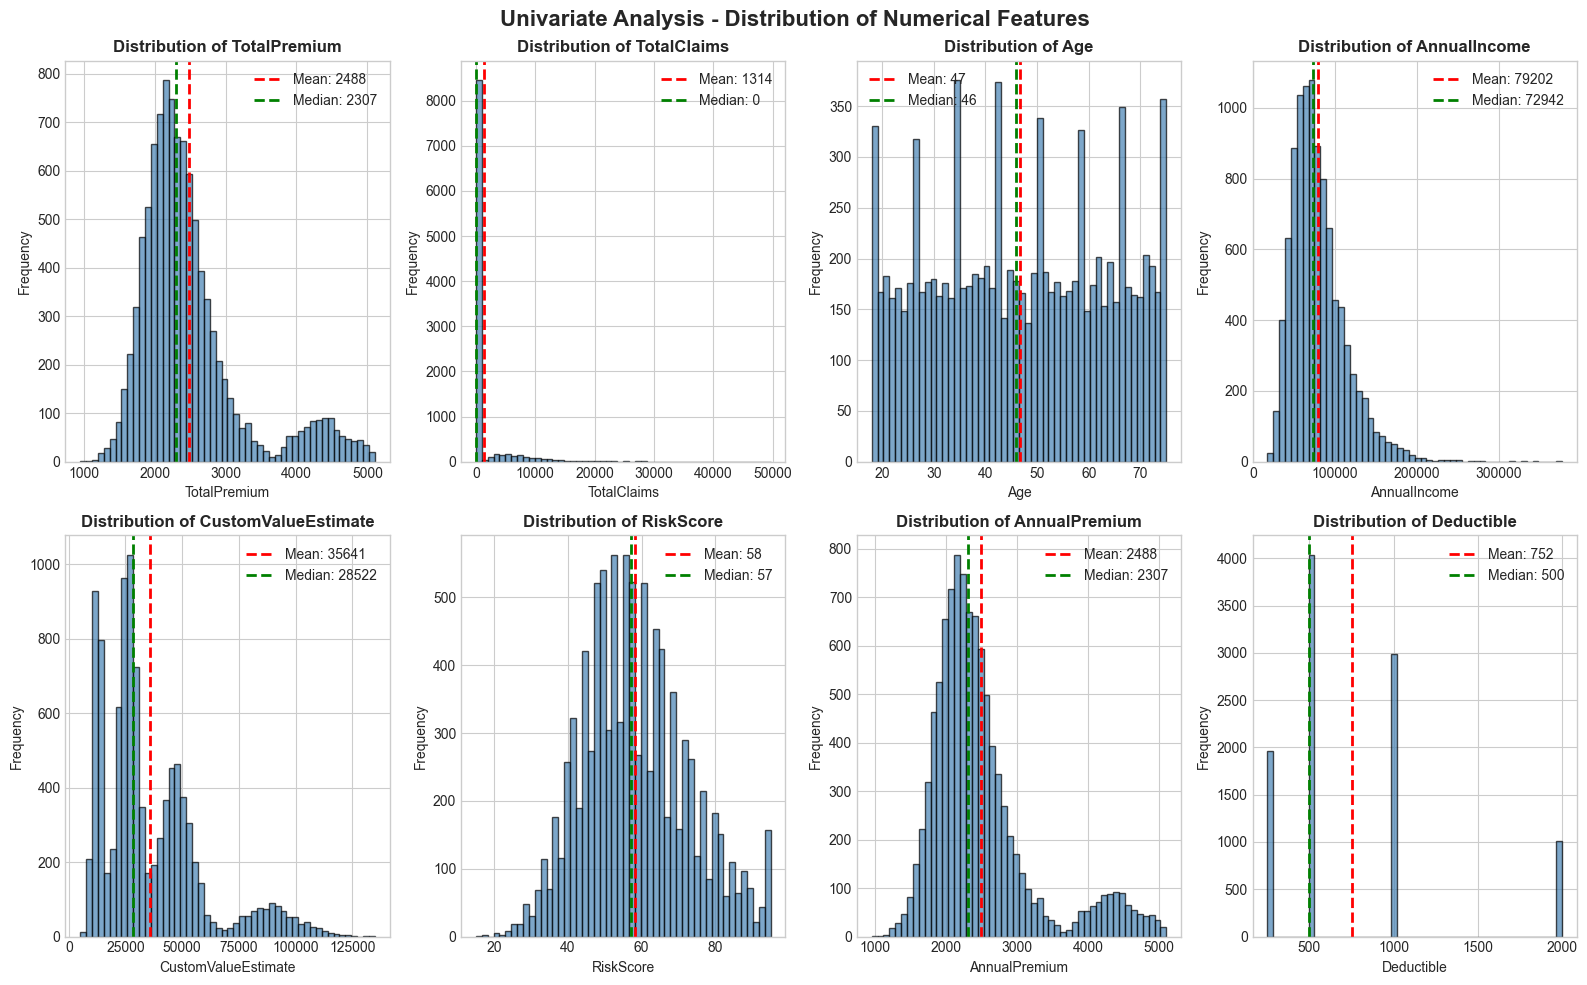

In [16]:
# Select numerical columns for analysis
numerical_cols = ['TotalPremium', 'TotalClaims', 'Age', 'AnnualIncome', 
                  'CustomValueEstimate', 'RiskScore', 'AnnualPremium', 'Deductible']

# Filter to columns that exist
existing_num = [col for col in numerical_cols if col in df.columns]

# Create histograms
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(existing_num):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.0f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.0f}')
    axes[i].legend()

# Remove empty subplots if any
for j in range(len(existing_num), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Univariate Analysis - Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

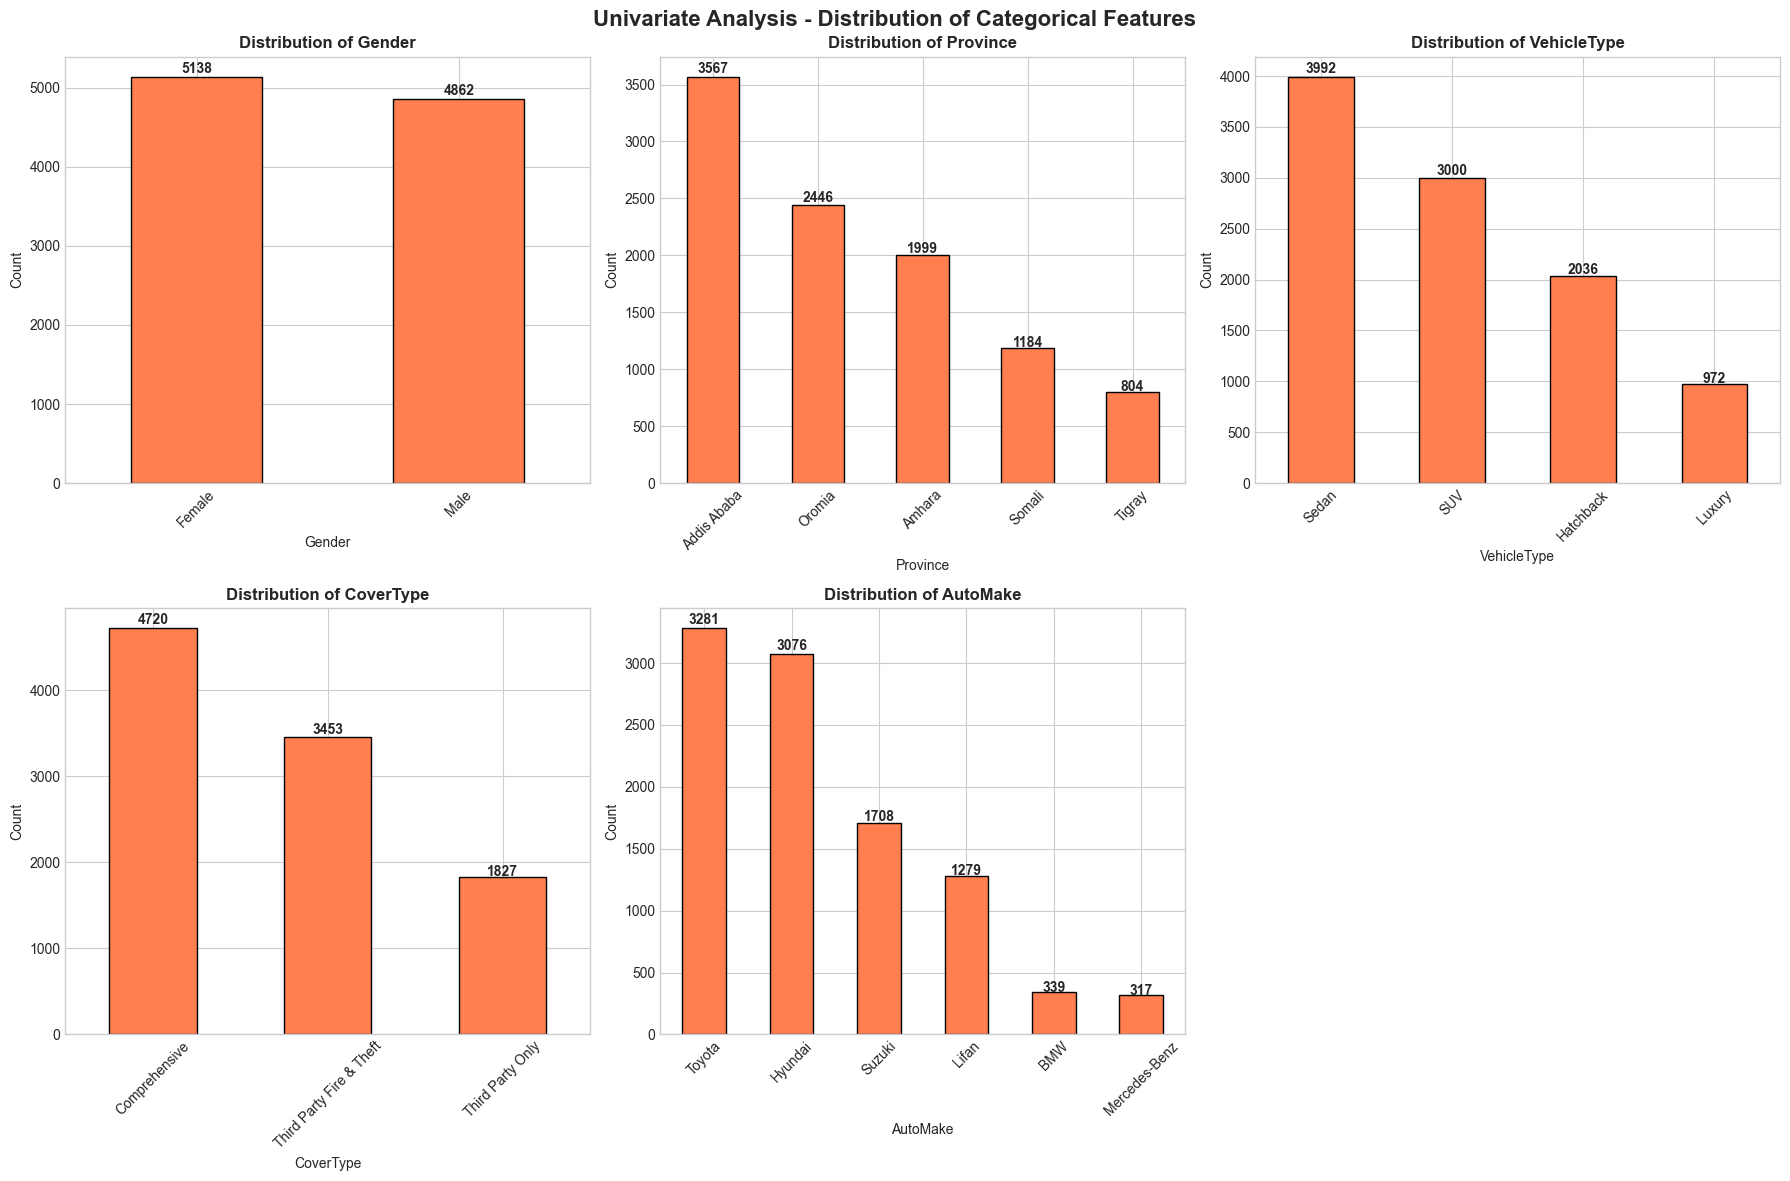

CATEGORICAL VARIABLE FREQUENCY TABLES

Gender:
Gender
Female    5138
Male      4862
Name: count, dtype: int64

Province:
Province
Addis Ababa    3567
Oromia         2446
Amhara         1999
Somali         1184
Tigray          804
Name: count, dtype: int64

VehicleType:
VehicleType
Sedan        3992
SUV          3000
Hatchback    2036
Luxury        972
Name: count, dtype: int64

CoverType:
CoverType
Comprehensive               4720
Third Party Fire & Theft    3453
Third Party Only            1827
Name: count, dtype: int64

AutoMake:
AutoMake
Toyota           3281
Hyundai          3076
Suzuki           1708
Lifan            1279
BMW               339
Mercedes-Benz     317
Name: count, dtype: int64


In [17]:
# Select categorical columns
categorical_cols = ['Gender', 'Province', 'VehicleType', 'CoverType', 'AutoMake']

# Filter to columns that exist
existing_cat = [col for col in categorical_cols if col in df.columns]

# Create bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(existing_cat):
    # Get value counts
    value_counts = df[col].value_counts()
    
    # Plot
    value_counts.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for j, v in enumerate(value_counts.values):
        axes[i].text(j, v + (v*0.01), str(v), ha='center', fontweight='bold')

# Remove empty subplot if any
if len(existing_cat) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Univariate Analysis - Distribution of Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print frequency tables
print("CATEGORICAL VARIABLE FREQUENCY TABLES")
for col in existing_cat:
    print(f"\n{col}:")
    print(df[col].value_counts())


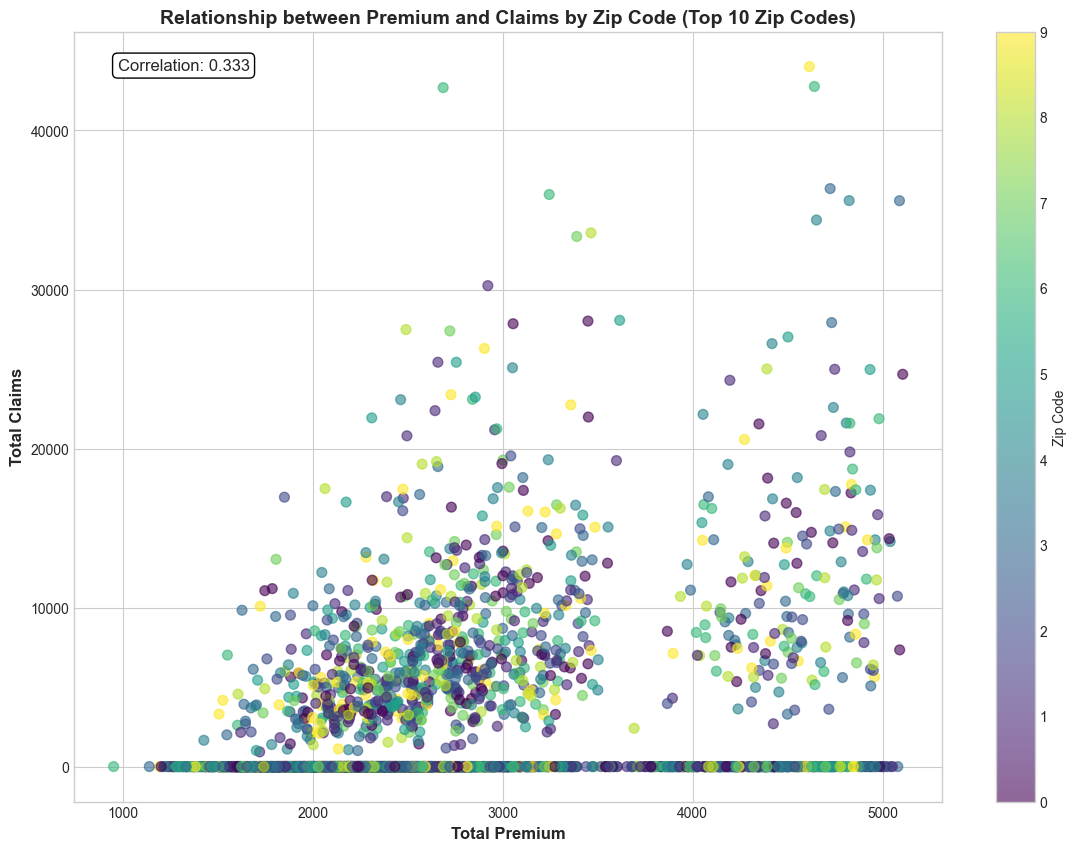

In [18]:
# Scatter plot: TotalPremium vs TotalClaims colored by ZipCode
plt.figure(figsize=(14, 10))

# Get top 10 zip codes by frequency for better visualization
top_zipcodes = df['ZipCode'].value_counts().head(10).index
df_top_zip = df[df['ZipCode'].isin(top_zipcodes)]

# Create scatter plot
scatter = plt.scatter(df_top_zip['TotalPremium'], 
                      df_top_zip['TotalClaims'], 
                      c=df_top_zip['ZipCode'].astype('category').cat.codes,
                      alpha=0.6, 
                      cmap='viridis',
                      s=50)

plt.colorbar(scatter, label='Zip Code')
plt.xlabel('Total Premium', fontsize=12, fontweight='bold')
plt.ylabel('Total Claims', fontsize=12, fontweight='bold')
plt.title('Relationship between Premium and Claims by Zip Code (Top 10 Zip Codes)', 
          fontsize=14, fontweight='bold')

# Add correlation annotation
correlation = df_top_zip['TotalPremium'].corr(df_top_zip['TotalClaims'])
plt.annotate(f'Correlation: {correlation:.3f}', 
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white"))

plt.show()

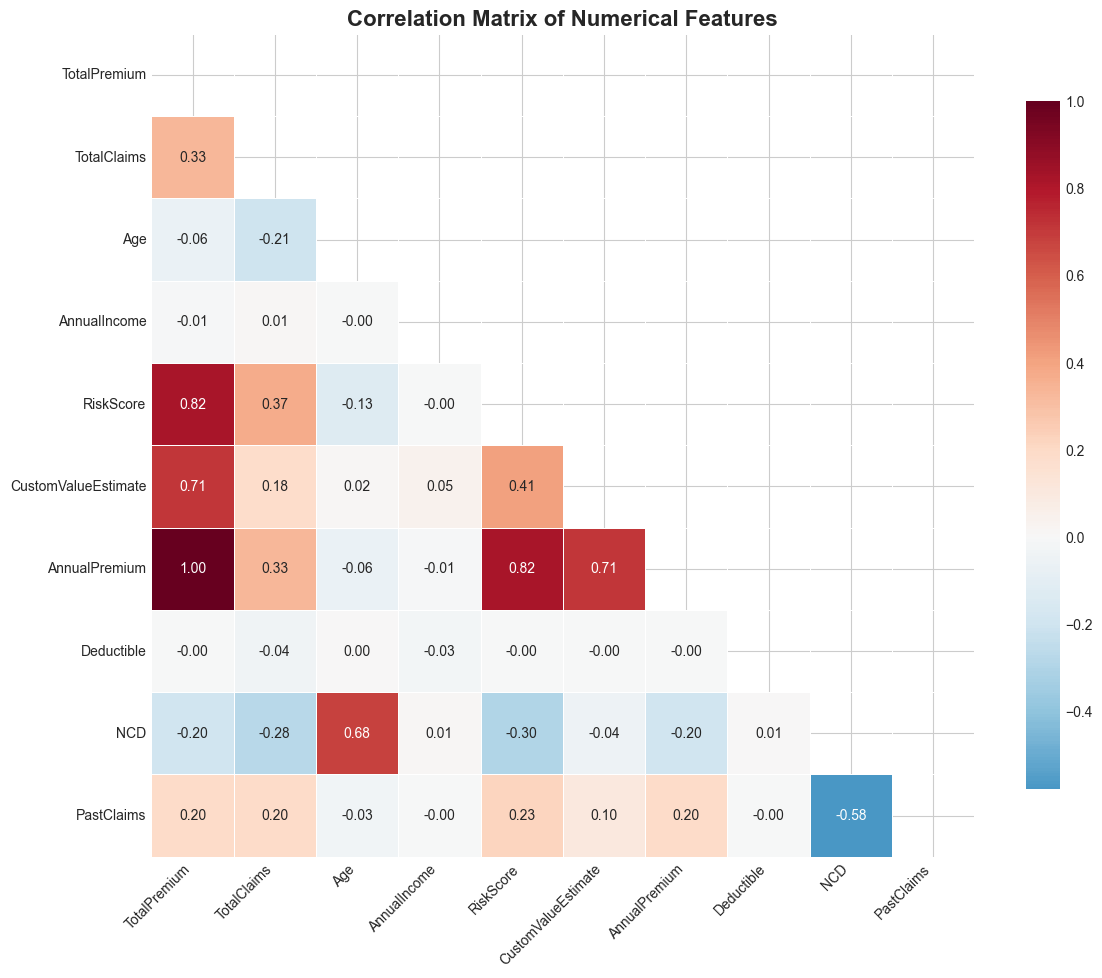

STRONGEST CORRELATIONS WITH TotalClaims
TotalClaims            1.000000
RiskScore              0.365128
TotalPremium           0.331404
AnnualPremium          0.331404
PastClaims             0.197054
CustomValueEstimate    0.182116
AnnualIncome           0.008045
Deductible            -0.039629
Age                   -0.205557
NCD                   -0.275695
Name: TotalClaims, dtype: float64
STRONGEST CORRELATIONS WITH TotalPremium
TotalPremium           1.000000
AnnualPremium          1.000000
RiskScore              0.822079
CustomValueEstimate    0.714546
TotalClaims            0.331404
PastClaims             0.197313
Deductible            -0.004238
AnnualIncome          -0.006664
Age                   -0.061422
NCD                   -0.198680
Name: TotalPremium, dtype: float64


In [19]:
# Correlation matrix for numerical features
# Select numerical columns for correlation analysis
correlation_cols = ['TotalPremium', 'TotalClaims', 'Age', 'AnnualIncome', 
                    'RiskScore', 'CustomValueEstimate', 'AnnualPremium', 
                    'Deductible', 'NCD', 'PastClaims']

existing_corr = [col for col in correlation_cols if col in df.columns]

# Calculate correlation matrix
corr_matrix = df[existing_corr].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("STRONGEST CORRELATIONS WITH TotalClaims")
corr_with_claims = corr_matrix['TotalClaims'].sort_values(ascending=False)
print(corr_with_claims)
print("STRONGEST CORRELATIONS WITH TotalPremium")
corr_with_premium = corr_matrix['TotalPremium'].sort_values(ascending=False)
print(corr_with_premium)

PROVINCE-WISE SUMMARY STATISTICS
            TotalPremium                  TotalClaims                    \
                    mean  median      sum        mean median        sum   
Province                                                                  
Addis Ababa      2497.16  2308.0  8907374     1304.52    0.0  4653210.0   
Amhara           2465.52  2287.0  4928566     1177.53    0.0  2353885.0   
Oromia           2481.46  2311.5  6069663     1333.22    0.0  3261061.0   
Somali           2521.10  2329.5  2984984     1542.73    0.0  1826593.0   
Tigray           2475.99  2295.0  1990692     1302.41    0.0  1047136.0   

            LossRatio   Margin  
                 mean     mean  
Province                        
Addis Ababa      0.44  1192.64  
Amhara           0.40  1287.98  
Oromia           0.45  1148.24  
Somali           0.52   978.37  
Tigray           0.44  1173.58  


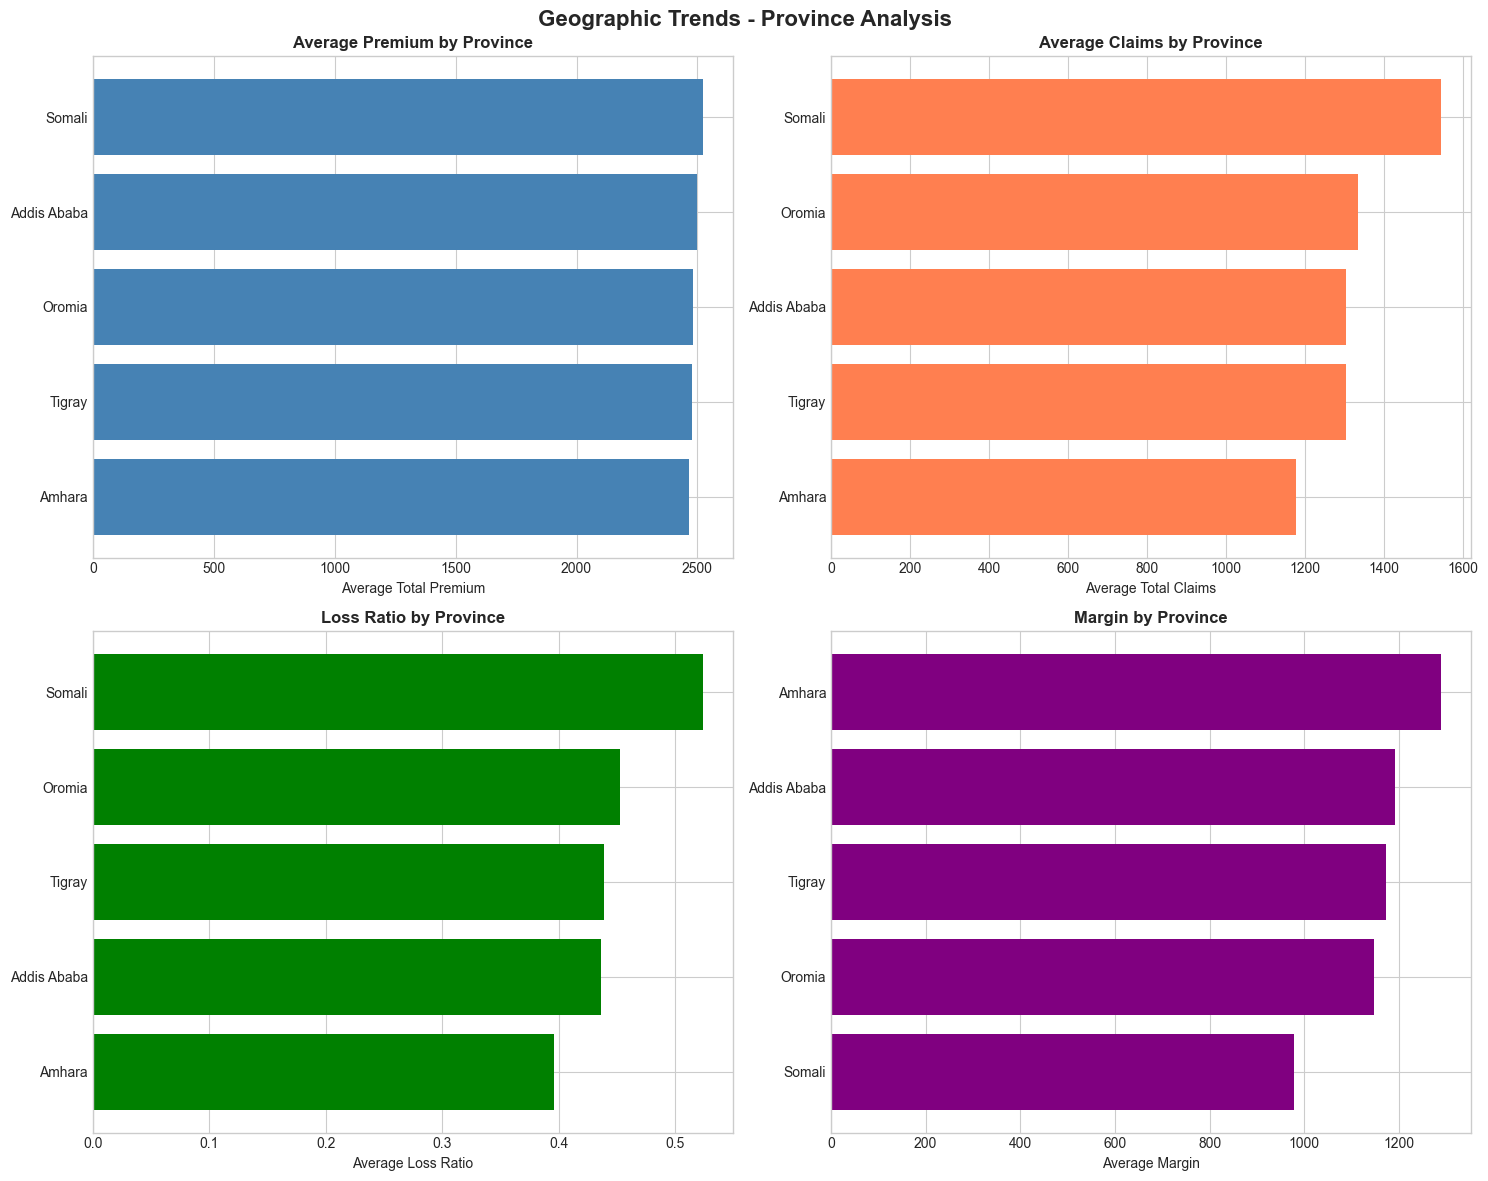

COVER TYPE DISTRIBUTION BY PROVINCE (%)
CoverType    Comprehensive  Third Party Fire & Theft  Third Party Only
Province                                                              
Addis Ababa           48.2                      33.9              17.9
Amhara                47.2                      33.0              19.8
Oromia                46.6                      35.5              17.9
Somali                46.4                      35.8              17.8
Tigray                46.0                      36.1              17.9


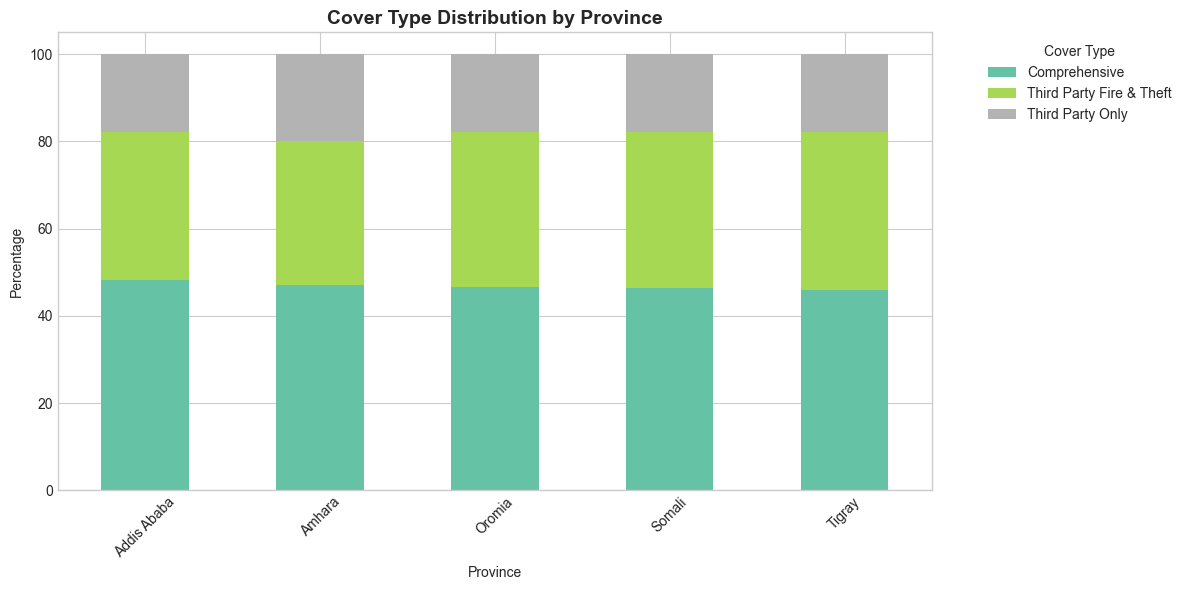

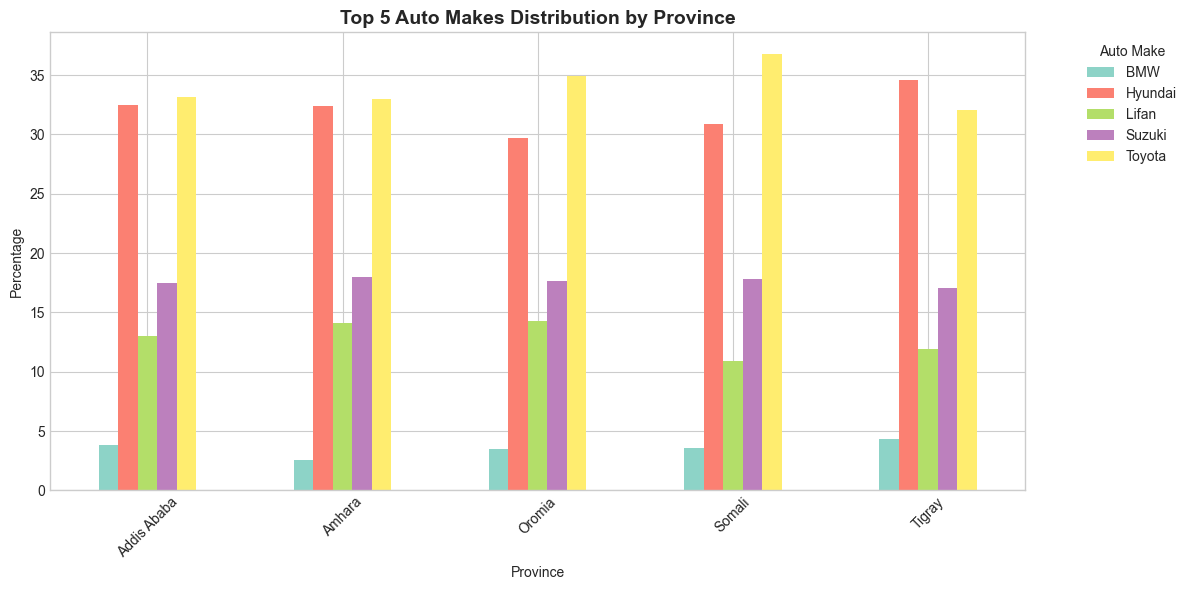

In [20]:
# Geographic analysis by province
if 'Province' in df.columns:
    # Group by province
    province_summary = df.groupby('Province').agg({
        'TotalPremium': ['mean', 'median', 'sum'],
        'TotalClaims': ['mean', 'median', 'sum'],
        'LossRatio': 'mean',
        'Margin': 'mean'
    }).round(2)
    print("PROVINCE-WISE SUMMARY STATISTICS")
    print(province_summary)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Average Premium by Province
    province_premium = df.groupby('Province')['TotalPremium'].mean().sort_values()
    axes[0, 0].barh(province_premium.index, province_premium.values, color='steelblue')
    axes[0, 0].set_xlabel('Average Total Premium')
    axes[0, 0].set_title('Average Premium by Province', fontweight='bold')
    
    # 2. Average Claims by Province
    province_claims = df.groupby('Province')['TotalClaims'].mean().sort_values()
    axes[0, 1].barh(province_claims.index, province_claims.values, color='coral')
    axes[0, 1].set_xlabel('Average Total Claims')
    axes[0, 1].set_title('Average Claims by Province', fontweight='bold')
    
    # 3. Loss Ratio by Province
    province_loss = df.groupby('Province')['LossRatio'].mean().sort_values()
    axes[1, 0].barh(province_loss.index, province_loss.values, color='green')
    axes[1, 0].set_xlabel('Average Loss Ratio')
    axes[1, 0].set_title('Loss Ratio by Province', fontweight='bold')
    
    # 4. Margin by Province
    province_margin = df.groupby('Province')['Margin'].mean().sort_values()
    axes[1, 1].barh(province_margin.index, province_margin.values, color='purple')
    axes[1, 1].set_xlabel('Average Margin')
    axes[1, 1].set_title('Margin by Province', fontweight='bold')
    
    plt.suptitle('Geographic Trends - Province Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Cover Type distribution by province
    if 'CoverType' in df.columns:
        cover_by_province = pd.crosstab(df['Province'], df['CoverType'], normalize='index') * 100
        print("COVER TYPE DISTRIBUTION BY PROVINCE (%)")
        print(cover_by_province.round(1))
        
        # Plot
        cover_by_province.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
        plt.title('Cover Type Distribution by Province', fontsize=14, fontweight='bold')
        plt.xlabel('Province')
        plt.ylabel('Percentage')
        plt.legend(title='Cover Type', bbox_to_anchor=(1.05, 1))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    # Auto Make distribution by province (top makes)
    if 'AutoMake' in df.columns:
        top_makes = df['AutoMake'].value_counts().head(5).index
        df_top_makes = df[df['AutoMake'].isin(top_makes)]
        make_by_province = pd.crosstab(df_top_makes['Province'], df_top_makes['AutoMake'], normalize='index') * 100
        
        make_by_province.plot(kind='bar', figsize=(12, 6), colormap='Set3')
        plt.title('Top 5 Auto Makes Distribution by Province', fontsize=14, fontweight='bold')
        plt.xlabel('Province')
        plt.ylabel('Percentage')
        plt.legend(title='Auto Make', bbox_to_anchor=(1.05, 1))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

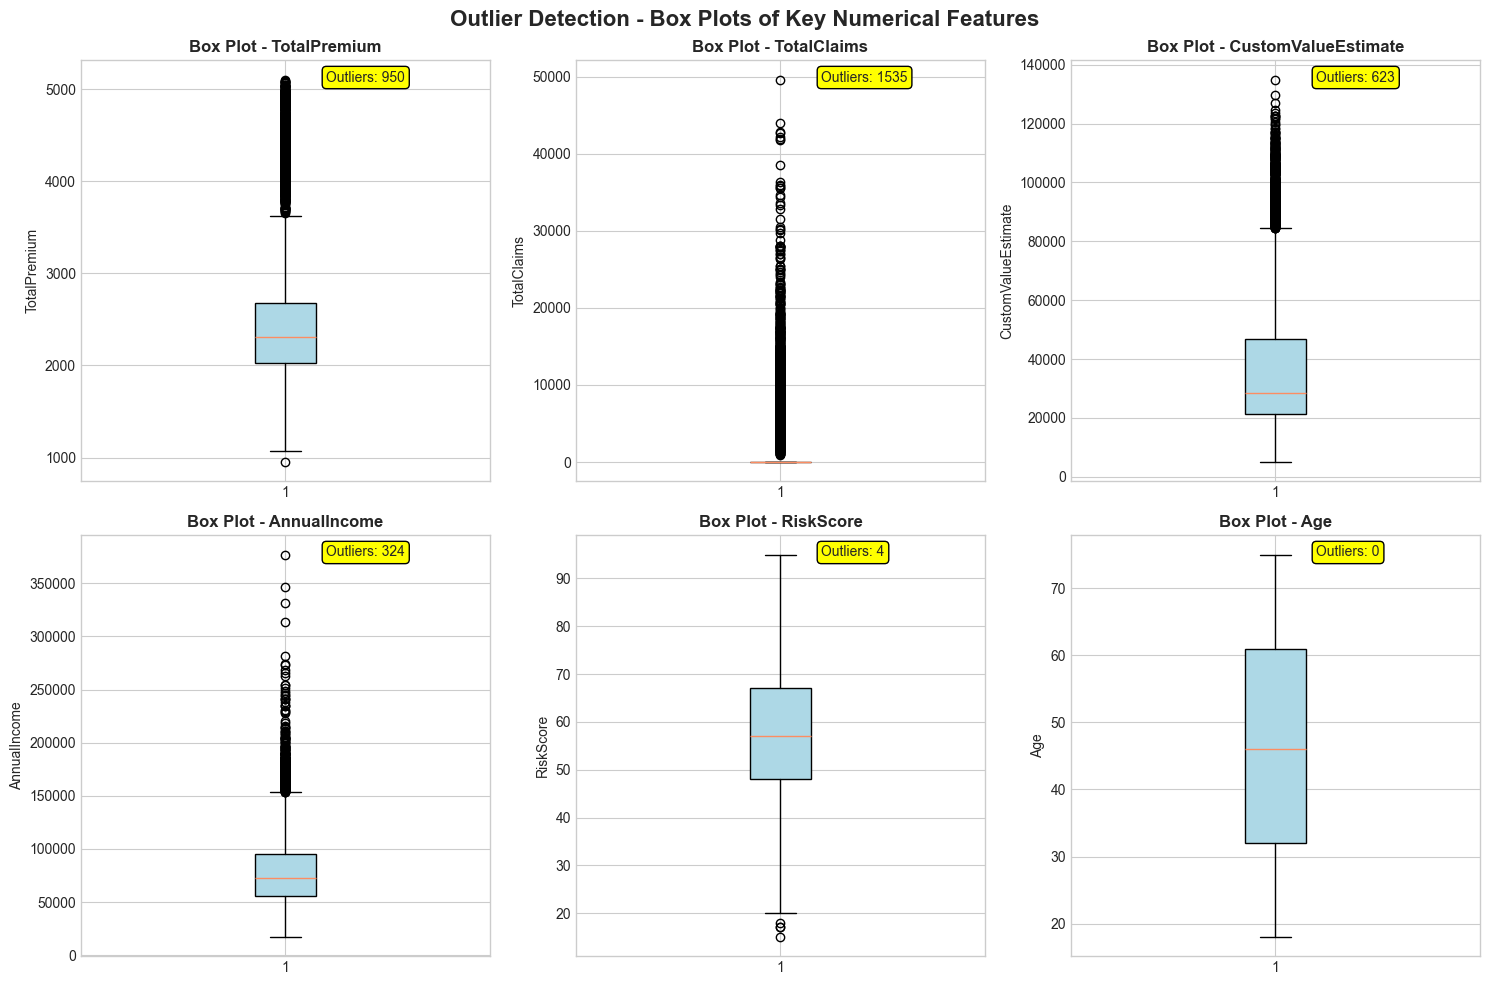

In [21]:
# Identify key numerical features for outlier detection
outlier_cols = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 
                'AnnualIncome', 'RiskScore', 'Age']

existing_outlier = [col for col in outlier_cols if col in df.columns]

# Create box plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(existing_outlier):
    axes[i].boxplot(df[col], vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Box Plot - {col}', fontweight='bold')
    axes[i].set_ylabel(col)
    
    # Add statistical annotations
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = len(df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))])
    axes[i].annotate(f'Outliers: {outliers}', 
                     xy=(0.6, 0.95), xycoords='axes fraction',
                     fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow"))

# Remove empty subplot if needed
for j in range(len(existing_outlier), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Detection - Box Plots of Key Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
print("OUTLIER ANALYSIS REPORT")
for col in existing_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_pct = (outlier_count / len(df)) * 100
    
    print(f"\n{col}:")
    print(f"  Q1 (25th percentile): {Q1:.2f}")
    print(f"  Q3 (75th percentile): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {outlier_count} ({outlier_pct:.2f}%)")
    
    if outlier_pct > 10:
        print(f"High outlier percentage - consider transformation")
    elif outlier_pct > 5:
        print(f"Moderate outlier percentage - investigate")
    else:
        print(f"Acceptable outlier percentage")

OUTLIER ANALYSIS REPORT

TotalPremium:
  Q1 (25th percentile): 2028.00
  Q3 (75th percentile): 2676.00
  IQR: 648.00
  Lower Bound: 1056.00
  Upper Bound: 3648.00
  Number of outliers: 950 (9.50%)
Moderate outlier percentage - investigate

TotalClaims:
  Q1 (25th percentile): 0.00
  Q3 (75th percentile): 0.00
  IQR: 0.00
  Lower Bound: 0.00
  Upper Bound: 0.00
  Number of outliers: 1535 (15.35%)
High outlier percentage - consider transformation

CustomValueEstimate:
  Q1 (25th percentile): 21442.75
  Q3 (75th percentile): 46721.00
  IQR: 25278.25
  Lower Bound: -16474.62
  Upper Bound: 84638.38
  Number of outliers: 623 (6.23%)
Moderate outlier percentage - investigate

AnnualIncome:
  Q1 (25th percentile): 56105.00
  Q3 (75th percentile): 95092.00
  IQR: 38987.00
  Lower Bound: -2375.50
  Upper Bound: 153572.50
  Number of outliers: 324 (3.24%)
Acceptable outlier percentage

RiskScore:
  Q1 (25th percentile): 48.00
  Q3 (75th percentile): 67.00
  IQR: 19.00
  Lower Bound: 19.50
  Uppe

LOSS RATIO ANALYSIS

OVERALL PORTFOLIO LOSS RATIO: 52.82%
   Total Premium Collected: R24,881,279.00
   Total Claims Paid: R13,141,885.00
Portfolio is profitable (Loss Ratio < 60%)
LOSS RATIO BY PROVINCE
Somali               :  61.19%
Oromia               :  53.73%
Tigray               :  52.60%
Addis Ababa          :  52.24%
Amhara               :  47.76%


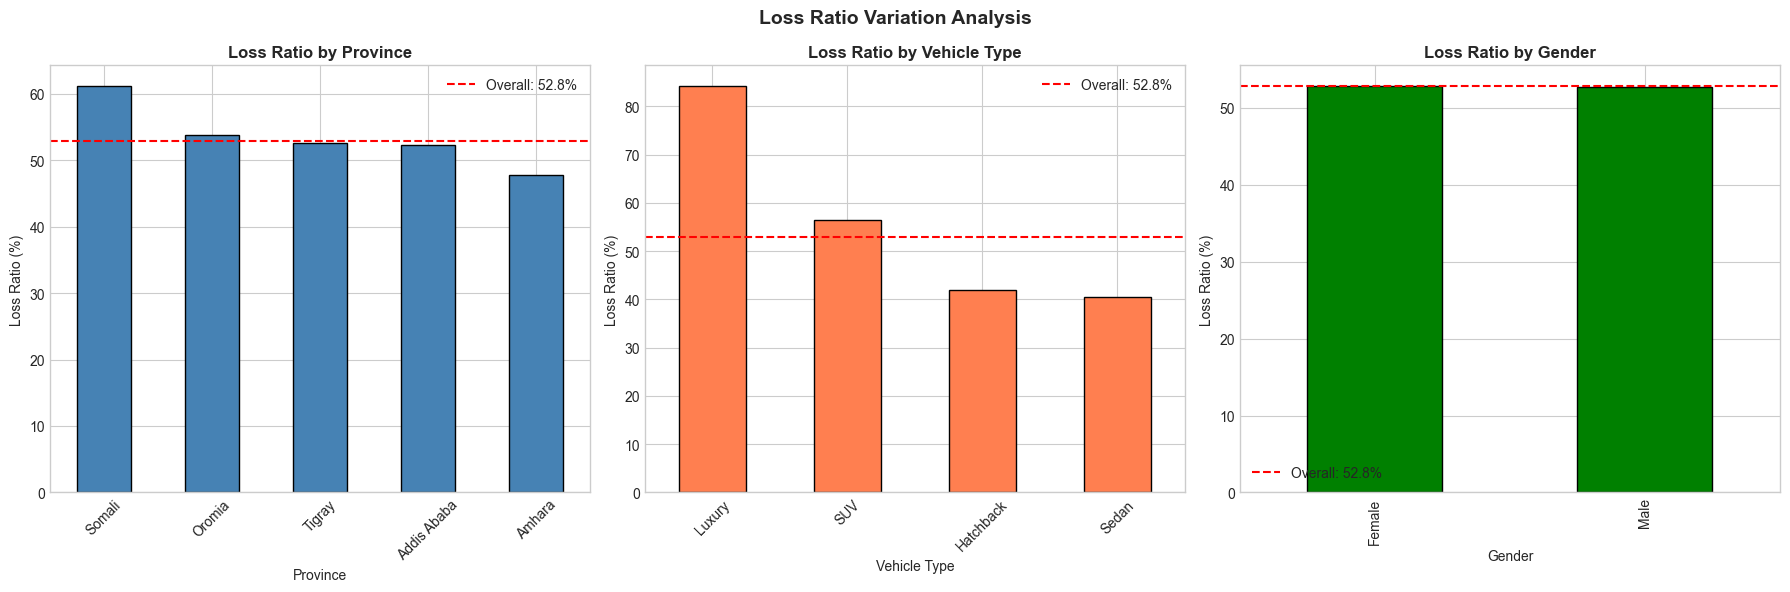

\KEY INSIGHTS - Loss Ratio:
   • Highest risk province: Somali (61.2%)
   • Lowest risk province: Amhara (47.8%)
   • Highest risk vehicle: Luxury (84.2%)
   • Lowest risk vehicle: Sedan (40.4%)


In [23]:

print("LOSS RATIO ANALYSIS")

total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
overall_loss_ratio = (total_claims / total_premium) * 100

print(f"\nOVERALL PORTFOLIO LOSS RATIO: {overall_loss_ratio:.2f}%")
print(f"   Total Premium Collected: R{total_premium:,.2f}")
print(f"   Total Claims Paid: R{total_claims:,.2f}")

if overall_loss_ratio < 60:
    print("Portfolio is profitable (Loss Ratio < 60%)")
elif overall_loss_ratio < 80:
    print("Portfolio has moderate profitability (60-80%)")
else:
    print("Portfolio is at risk (Loss Ratio > 80%)")

# Loss Ratio by Province
print("LOSS RATIO BY PROVINCE")

province_loss = df.groupby('Province').apply(
    lambda x: (x['TotalClaims'].sum() / x['TotalPremium'].sum()) * 100
).sort_values(ascending=False)

for province, loss_ratio in province_loss.items():
    print(f"{province:20} : {loss_ratio:6.2f}%")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Province Loss Ratio
province_loss.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Loss Ratio by Province', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Province')
axes[0].set_ylabel('Loss Ratio (%)')
axes[0].axhline(overall_loss_ratio, color='red', linestyle='--', label=f'Overall: {overall_loss_ratio:.1f}%')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Loss Ratio by VehicleType
vehicle_loss = df.groupby('VehicleType').apply(
    lambda x: (x['TotalClaims'].sum() / x['TotalPremium'].sum()) * 100
).sort_values(ascending=False)

vehicle_loss.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Loss Ratio by Vehicle Type', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Vehicle Type')
axes[1].set_ylabel('Loss Ratio (%)')
axes[1].axhline(overall_loss_ratio, color='red', linestyle='--', label=f'Overall: {overall_loss_ratio:.1f}%')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Loss Ratio by Gender
gender_loss = df.groupby('Gender').apply(
    lambda x: (x['TotalClaims'].sum() / x['TotalPremium'].sum()) * 100
).sort_values(ascending=False)

gender_loss.plot(kind='bar', ax=axes[2], color='green', edgecolor='black')
axes[2].set_title('Loss Ratio by Gender', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Loss Ratio (%)')
axes[2].axhline(overall_loss_ratio, color='red', linestyle='--', label=f'Overall: {overall_loss_ratio:.1f}%')
axes[2].legend()

plt.suptitle('Loss Ratio Variation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print insights
print("\KEY INSIGHTS - Loss Ratio:")
print(f"   • Highest risk province: {province_loss.index[0]} ({province_loss.iloc[0]:.1f}%)")
print(f"   • Lowest risk province: {province_loss.index[-1]} ({province_loss.iloc[-1]:.1f}%)")
print(f"   • Highest risk vehicle: {vehicle_loss.index[0]} ({vehicle_loss.iloc[0]:.1f}%)")
print(f"   • Lowest risk vehicle: {vehicle_loss.index[-1]} ({vehicle_loss.iloc[-1]:.1f}%)")

QUESTION 2: DISTRIBUTIONS & OUTLIER ANALYSIS

DISTRIBUTION STATISTICS:

TotalPremium:
   Mean:   R2,488.13
   Median: R2,307.00
   Std Dev: R735.67
   Min:    R951.00
   Max:    R5,105.00
   Skewness: 1.58

TotalClaims:
   Mean:   R1,314.19
   Median: R0.00
   Std Dev: R3,921.86
   Min:    R0.00
   Max:    R49,623.00
   Skewness: 4.37

CustomValueEstimate:
   Mean:   R35,640.60
   Median: R28,522.00
   Std Dev: R22,353.99
   Min:    R5,022.00
   Max:    R134,914.00
   Skewness: 1.38
DETAILED OUTLIER ANALYSIS

TotalClaims:
   Outlier count: 1,535 (15.35%)
   Lower bound: 0.00
   Upper bound: 0.00
 Significant outliers detected - may skew analysis
   Consider: Log transformation or capping

CustomValueEstimate:
   Outlier count: 623 (6.23%)
   Lower bound: -16474.62
   Upper bound: 84638.38
 Significant outliers detected - may skew analysis
   Consider: Log transformation or capping


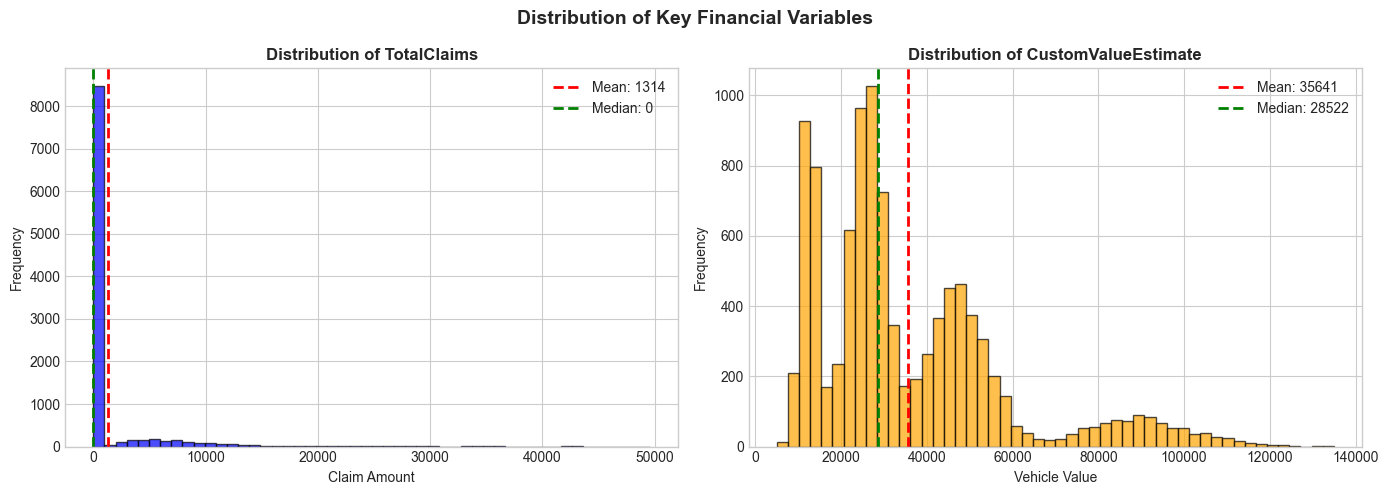

In [24]:
print("QUESTION 2: DISTRIBUTIONS & OUTLIER ANALYSIS")
# Key financial variables
financial_vars = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate']

print("\nDISTRIBUTION STATISTICS:")
for var in financial_vars:
    if var in df.columns:
        print(f"\n{var}:")
        print(f"   Mean:   R{df[var].mean():,.2f}")
        print(f"   Median: R{df[var].median():,.2f}")
        print(f"   Std Dev: R{df[var].std():,.2f}")
        print(f"   Min:    R{df[var].min():,.2f}")
        print(f"   Max:    R{df[var].max():,.2f}")
        print(f"   Skewness: {df[var].skew():.2f}")

# Outlier analysis for TotalClaims
print("DETAILED OUTLIER ANALYSIS")
for var in ['TotalClaims', 'CustomValueEstimate']:
    if var in df.columns:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
        outlier_pct = (len(outliers) / len(df)) * 100
        
        print(f"\n{var}:")
        print(f"   Outlier count: {len(outliers):,} ({outlier_pct:.2f}%)")
        print(f"   Lower bound: {lower_bound:.2f}")
        print(f"   Upper bound: {upper_bound:.2f}")
        
        if outlier_pct > 5:
            print(f" Significant outliers detected - may skew analysis")
            print(f"   Consider: Log transformation or capping")
        else:
            print(f"Outlier level is manageable")

# Visualize distributions with outliers highlighted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TotalClaims distribution
if 'TotalClaims' in df.columns:
    axes[0].hist(df['TotalClaims'], bins=50, edgecolor='black', alpha=0.7, color='blue')
    axes[0].axvline(df['TotalClaims'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["TotalClaims"].mean():.0f}')
    axes[0].axvline(df['TotalClaims'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["TotalClaims"].median():.0f}')
    axes[0].set_title('Distribution of TotalClaims', fontweight='bold')
    axes[0].set_xlabel('Claim Amount')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

# CustomValueEstimate distribution
if 'CustomValueEstimate' in df.columns:
    axes[1].hist(df['CustomValueEstimate'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].axvline(df['CustomValueEstimate'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["CustomValueEstimate"].mean():.0f}')
    axes[1].axvline(df['CustomValueEstimate'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["CustomValueEstimate"].median():.0f}')
    axes[1].set_title('Distribution of CustomValueEstimate', fontweight='bold')
    axes[1].set_xlabel('Vehicle Value')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()

plt.suptitle('Distribution of Key Financial Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

TEMPORAL TRENDS ANALYSIS
\MONTHLY TRENDS SUMMARY:
           TotalClaims_Sum  AvgClaimAmount  TotalPremium_Sum  ClaimCount  \
YearMonth                                                                  
2024-01           764324.0         1369.76           1413501          78   
2024-02           661946.0         1246.60           1333583          76   
2024-03           725682.0         1348.85           1327698          81   
2024-04           751881.0         1359.64           1380709          89   
2024-05           941073.0         1636.65           1423373          99   
2024-06           810706.0         1405.04           1440271          94   
2024-07           660642.0         1232.54           1343126          77   
2024-08           830639.0         1407.86           1437183          91   
2024-09           665107.0         1170.96           1434450          79   
2024-10           707146.0         1281.06           1368374          90   
2024-11           790842.0         146

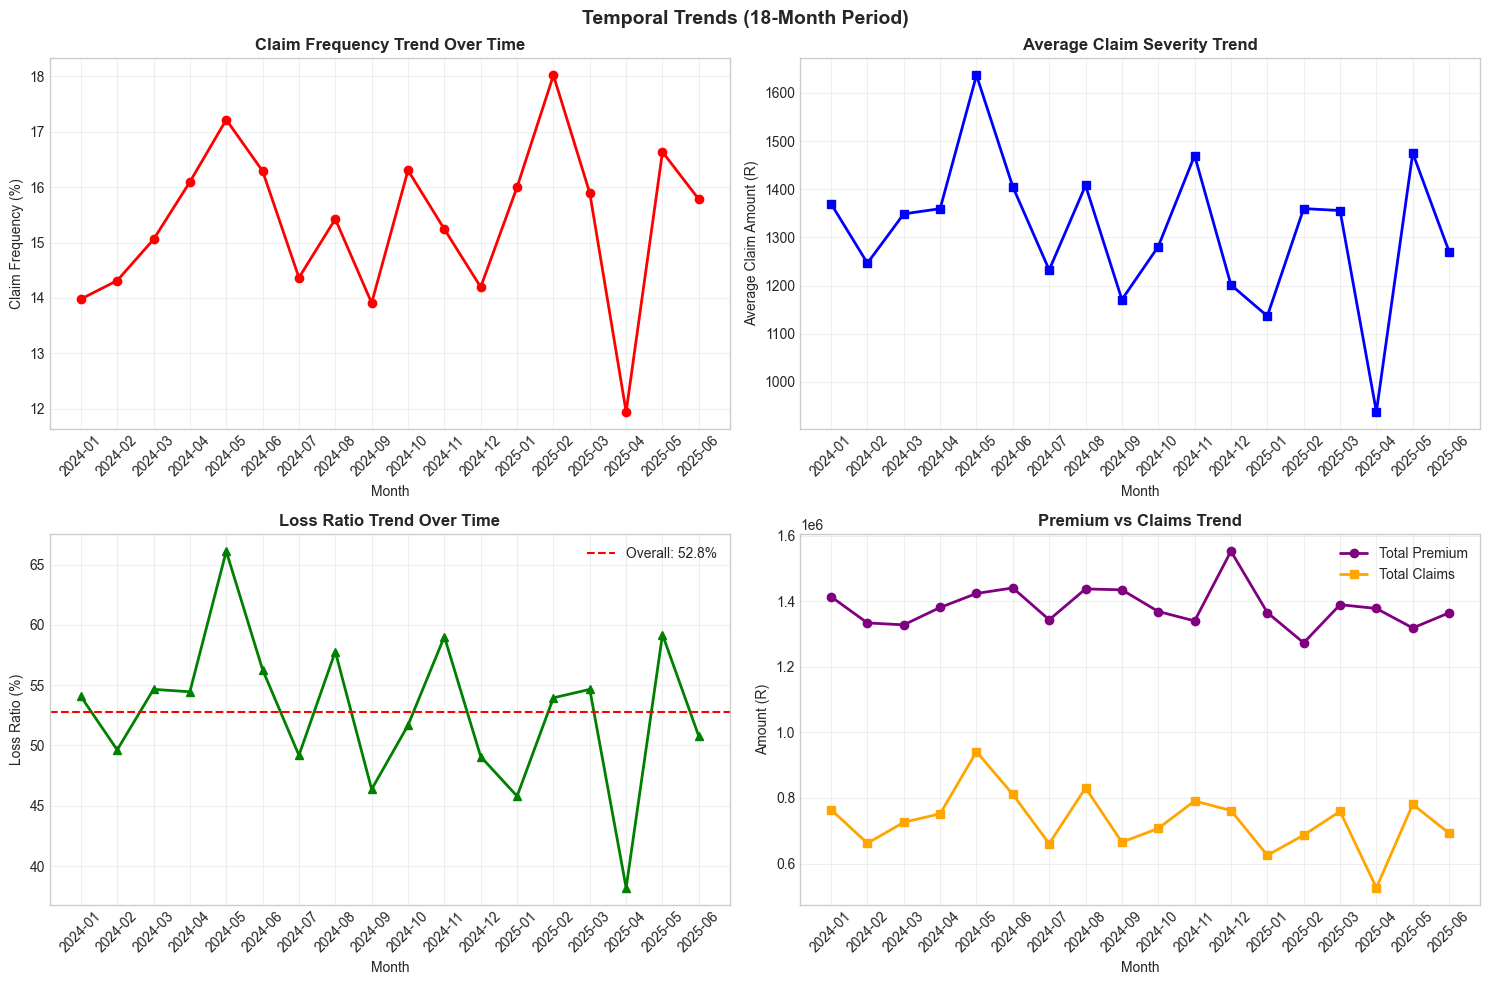

TEMPORAL INSIGHTS:
   • Maximum monthly change in claim frequency: 39.3%
   • Maximum monthly change in claim severity: 57.3%
   • Highest claim frequency month: Month 5
   • Lowest claim frequency month: Month 9


In [25]:
print("TEMPORAL TRENDS ANALYSIS")

# Ensure TransactionDate is datetime
if 'TransactionDate' in df.columns:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    
    # Extract year-month for grouping
    df['YearMonth'] = df['TransactionDate'].dt.to_period('M')
    
    # Monthly trends
    monthly_claims = df.groupby('YearMonth').agg({
        'TotalClaims': ['sum', 'mean'],
        'TotalPremium': 'sum',
        'Claimed': 'sum'
    }).round(2)
    
    monthly_claims.columns = ['TotalClaims_Sum', 'AvgClaimAmount', 'TotalPremium_Sum', 'ClaimCount']
    monthly_claims['ClaimFrequency'] = (monthly_claims['ClaimCount'] / df.groupby('YearMonth').size()) * 100
    monthly_claims['LossRatio'] = (monthly_claims['TotalClaims_Sum'] / monthly_claims['TotalPremium_Sum']) * 100
    
    print("\MONTHLY TRENDS SUMMARY:")
    print(monthly_claims)
    
    # Create temporal visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Claim Frequency over time
    axes[0, 0].plot(monthly_claims.index.astype(str), monthly_claims['ClaimFrequency'], 
                    marker='o', linewidth=2, markersize=6, color='red')
    axes[0, 0].set_title('Claim Frequency Trend Over Time', fontweight='bold')
    axes[0, 0].set_xlabel('Month')
    axes[0, 0].set_ylabel('Claim Frequency (%)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Average Claim Amount over time
    axes[0, 1].plot(monthly_claims.index.astype(str), monthly_claims['AvgClaimAmount'], 
                    marker='s', linewidth=2, markersize=6, color='blue')
    axes[0, 1].set_title('Average Claim Severity Trend', fontweight='bold')
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Average Claim Amount (R)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Loss Ratio over time
    axes[1, 0].plot(monthly_claims.index.astype(str), monthly_claims['LossRatio'], 
                    marker='^', linewidth=2, markersize=6, color='green')
    axes[1, 0].set_title('Loss Ratio Trend Over Time', fontweight='bold')
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Loss Ratio (%)')
    axes[1, 0].axhline(overall_loss_ratio, color='red', linestyle='--', label=f'Overall: {overall_loss_ratio:.1f}%')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Total Premium vs Claims over time
    axes[1, 1].plot(monthly_claims.index.astype(str), monthly_claims['TotalPremium_Sum'], 
                    marker='o', linewidth=2, markersize=6, label='Total Premium', color='purple')
    axes[1, 1].plot(monthly_claims.index.astype(str), monthly_claims['TotalClaims_Sum'], 
                    marker='s', linewidth=2, markersize=6, label='Total Claims', color='orange')
    axes[1, 1].set_title('Premium vs Claims Trend', fontweight='bold')
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('Amount (R)')
    axes[1, 1].legend()
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Temporal Trends (18-Month Period)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Identify significant changes
    print("TEMPORAL INSIGHTS:")
    freq_change = monthly_claims['ClaimFrequency'].pct_change().abs().max() * 100
    severity_change = monthly_claims['AvgClaimAmount'].pct_change().abs().max() * 100
    
    print(f"   • Maximum monthly change in claim frequency: {freq_change:.1f}%")
    print(f"   • Maximum monthly change in claim severity: {severity_change:.1f}%")
    
    # Check for seasonality
    monthly_claims['Month'] = monthly_claims.index.month
    seasonal_pattern = monthly_claims.groupby('Month')['ClaimFrequency'].mean()
    highest_season = seasonal_pattern.idxmax()
    lowest_season = seasonal_pattern.idxmin()
    
    print(f"   • Highest claim frequency month: Month {highest_season}")
    print(f"   • Lowest claim frequency month: Month {lowest_season}")
else:
    print("TransactionDate column not found - cannot perform temporal analysis")

VEHICLE RISK ANALYSIS
TOP 10 HIGHEST CLAIM AMOUNTS BY VEHICLE MAKE:
                      mean        sum  count
AutoMake                                    
Mercedes-Benz  3787.012618  1200483.0    317
BMW            3362.890855  1140020.0    339
Toyota         1372.520878  4503241.0   3281
Suzuki         1122.025761  1916420.0   1708
Hyundai        1042.739272  3207466.0   3076
Lifan           918.103987  1174255.0   1279
BOTTOM 10 LOWEST CLAIM AMOUNTS BY VEHICLE MAKE:
                      mean        sum  count
AutoMake                                    
Mercedes-Benz  3787.012618  1200483.0    317
BMW            3362.890855  1140020.0    339
Toyota         1372.520878  4503241.0   3281
Suzuki         1122.025761  1916420.0   1708
Hyundai        1042.739272  3207466.0   3076
Lifan           918.103987  1174255.0   1279
TOP 10 HIGHEST CLAIM AMOUNTS BY VEHICLE MODEL:
                     mean        sum  count
VehicleModel                               
Land Cruiser  3888.303797  12

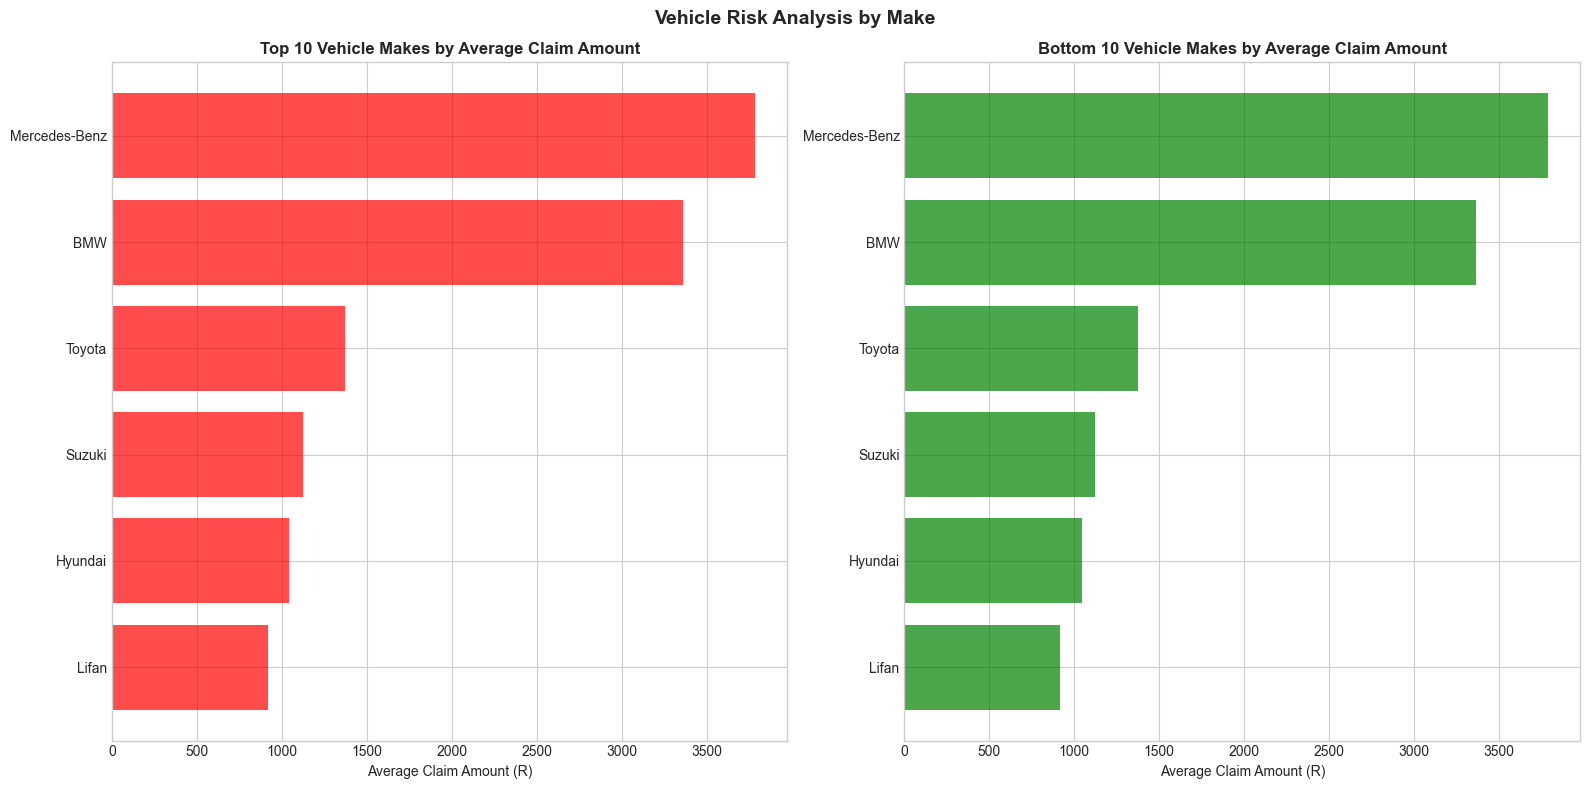

VEHICLE RISK INSIGHTS:
   • Highest risk make: Mercedes-Benz (Avg Claim: R3,787.01)
   • Lowest risk make: Lifan (Avg Claim: R918.10)
   • Risk ratio (highest/lowest): 4.1x


In [26]:

print("VEHICLE RISK ANALYSIS")

# Analyze by AutoMake
if 'AutoMake' in df.columns and 'TotalClaims' in df.columns:
    # Average claim amount by make
    make_claims = df.groupby('AutoMake')['TotalClaims'].agg(['mean', 'sum', 'count'])
    make_claims = make_claims.sort_values('mean', ascending=False)
    
    print("TOP 10 HIGHEST CLAIM AMOUNTS BY VEHICLE MAKE:")
    print(make_claims.head(10).to_string())
    
    print("BOTTOM 10 LOWEST CLAIM AMOUNTS BY VEHICLE MAKE:")
    print(make_claims.tail(10).to_string())
    
    # Analyze by VehicleModel
    if 'VehicleModel' in df.columns:
        model_claims = df.groupby('VehicleModel')['TotalClaims'].agg(['mean', 'sum', 'count'])
        model_claims = model_claims[model_claims['count'] >= 5]  # Only models with at least 5 policies
        model_claims = model_claims.sort_values('mean', ascending=False)
        
        print("TOP 10 HIGHEST CLAIM AMOUNTS BY VEHICLE MODEL:")
        print(model_claims.head(10).to_string())
        
        print("BOTTOM 10 LOWEST CLAIM AMOUNTS BY VEHICLE MODEL:")
        print(model_claims.tail(10).to_string())
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Top 10 makes by average claim
    top_makes = make_claims.head(10)
    axes[0].barh(range(len(top_makes)), top_makes['mean'].values, color='red', alpha=0.7)
    axes[0].set_yticks(range(len(top_makes)))
    axes[0].set_yticklabels(top_makes.index)
    axes[0].set_xlabel('Average Claim Amount (R)')
    axes[0].set_title('Top 10 Vehicle Makes by Average Claim Amount', fontweight='bold')
    axes[0].invert_yaxis()
    
    # Bottom 10 makes by average claim
    bottom_makes = make_claims.tail(10)
    axes[1].barh(range(len(bottom_makes)), bottom_makes['mean'].values, color='green', alpha=0.7)
    axes[1].set_yticks(range(len(bottom_makes)))
    axes[1].set_yticklabels(bottom_makes.index)
    axes[1].set_xlabel('Average Claim Amount (R)')
    axes[1].set_title('Bottom 10 Vehicle Makes by Average Claim Amount', fontweight='bold')
    axes[1].invert_yaxis()
    
    plt.suptitle('Vehicle Risk Analysis by Make', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print("VEHICLE RISK INSIGHTS:")
    print(f"   • Highest risk make: {make_claims.index[0]} (Avg Claim: R{make_claims.iloc[0]['mean']:,.2f})")
    print(f"   • Lowest risk make: {make_claims.index[-1]} (Avg Claim: R{make_claims.iloc[-1]['mean']:,.2f})")
    print(f"   • Risk ratio (highest/lowest): {make_claims.iloc[0]['mean'] / make_claims.iloc[-1]['mean']:.1f}x")